In [1]:
import os
import json
import pickle
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

import timm
import seaborn as sns

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

BASE_PATH = Path(r"E:\Thesis")
HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

OUT_DIR = BASE_PATH / "outputs" / "convnextv2_tiny_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 2   # safe start for GTX 1650
EPOCHS = 20
NUM_CLASSES = 4

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Output folder:", OUT_DIR)

Device: cuda
Output folder: E:\Thesis\outputs\convnextv2_tiny_baseline


In [3]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [4]:
conv_models = [m for m in timm.list_models("*convnextv2*") if "tiny" in m.lower()]
print(conv_models)

['convnextv2_tiny']


In [5]:
model_name = "convnextv2_tiny.fcmae_ft_in1k"

In [6]:
ham = pd.read_csv(HAM_PATH / "HAM10000_metadata.csv")
pad = pd.read_csv(PAD_PATH / "metadata.csv")

print("HAM shape:", ham.shape)
print("PAD shape:", pad.shape)

HAM shape: (10015, 8)
PAD shape: (2298, 26)


In [7]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

print("HAM class counts:")
print(ham_4["label"].value_counts())

print("\nPAD class counts:")
print(pad_4["label"].value_counts())

HAM class counts:
label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64

PAD class counts:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [8]:
ham_4["image_path"] = ham_4["image_id"].apply(lambda x: str(HAM_IMAGE_DIR / f"{x}.jpg"))
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))

ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print("HAM exists:")
print(ham_4["exists"].value_counts())

print("\nPAD exists:")
print(pad_4["exists"].value_counts())

HAM exists:
exists
True    8659
Name: count, dtype: int64

PAD exists:
exists
True    1871
Name: count, dtype: int64


In [9]:
print("HAM labels:", sorted(ham_4["label"].unique()))
print("PAD labels:", sorted(pad_4["label"].unique()))
print("Same classes:", set(ham_4["label"].unique()) == set(pad_4["label"].unique()))

HAM labels: ['ACK', 'BCC', 'MEL', 'NEV']
PAD labels: ['ACK', 'BCC', 'MEL', 'NEV']
Same classes: True


In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(gss.split(ham_4, groups=ham_4["lesion_id"]))

train_df = ham_4.iloc[train_idx].copy()
val_df = ham_4.iloc[val_idx].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("PAD test samples:", len(pad_4))

Training samples: 6932
Validation samples: 1727
PAD test samples: 1871


In [11]:
train_df.to_csv(OUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUT_DIR / "val_split.csv", index=False)
pad_4.to_csv(OUT_DIR / "pad_test_split.csv", index=False)

In [12]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_to_idx=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = row["label"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        y = self.label_to_idx[label]
        return image, torch.tensor(y, dtype=torch.long)

In [13]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

pad_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [14]:
label_to_idx = {"ACK": 0, "BCC": 1, "MEL": 2, "NEV": 3}
idx_to_label = {v: k for k, v in label_to_idx.items()}

train_dataset = SkinLesionDataset(train_df, transform=train_transform, label_to_idx=label_to_idx)
val_dataset = SkinLesionDataset(val_df, transform=val_transform, label_to_idx=label_to_idx)
pad_dataset = SkinLesionDataset(pad_4, transform=pad_transform, label_to_idx=label_to_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
pad_loader = DataLoader(
    pad_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("PAD batches:", len(pad_loader))

Train batches: 3466
Val batches: 864
PAD batches: 936


In [15]:
model_name = "convnextv2_tiny.fcmae_ft_in1k"

if model_name not in timm.list_models():
    print("Exact model name not found. Available similar models:")
    print([m for m in timm.list_models("*convnextv2*") if "tiny" in m.lower()])

model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)
print("Model loaded:", model_name)

Exact model name not found. Available similar models:
['convnextv2_tiny']


model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\parth\miniconda3\envs\tf\lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\parth\.cache\huggingface\hub\models--timm--convnextv2_tiny.fcmae_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Model loaded: convnextv2_tiny.fcmae_ft_in1k


In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

In [17]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_probs = []
    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)

            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    return running_loss / total, correct / total, all_probs, all_preds, all_true

In [18]:
best_val_acc = -1.0
best_epoch = -1
patience = 5
patience_counter = 0
history = []

best_path = OUT_DIR / "best_convnextv2_tiny.pth"
last_path = OUT_DIR / "last_convnextv2_tiny.pth"
history_csv = OUT_DIR / "history.csv"
history_json = OUT_DIR / "history.json"
history_pkl = OUT_DIR / "history.pkl"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device
    )

    val_loss, val_acc, val_probs, val_preds, val_true = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    epoch_log = {
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "lr": float(current_lr)
    }
    history.append(epoch_log)

    pd.DataFrame(history).to_csv(history_csv, index=False)

    with open(history_json, "w") as f:
        json.dump(history, f, indent=2)

    with open(history_pkl, "wb") as f:
        pickle.dump(history, f)

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history
    }, last_path)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "history": history
        }, best_path)

        print(f"Saved best model at epoch {epoch+1} with val_acc={val_acc:.4f}")
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

print("Training finished.")
print("Best val accuracy:", best_val_acc)
print("Best epoch:", best_epoch)

Saved best model at epoch 1 with val_acc=0.7805
Epoch 01/20 | train_loss=0.7644 train_acc=0.7716 | val_loss=0.7568 val_acc=0.7805 | lr=1.00e-04
Epoch 02/20 | train_loss=0.7298 train_acc=0.7714 | val_loss=0.7536 val_acc=0.7805 | lr=1.00e-04
Epoch 03/20 | train_loss=0.7593 train_acc=0.7728 | val_loss=0.7524 val_acc=0.7805 | lr=1.00e-04
Epoch 04/20 | train_loss=0.7588 train_acc=0.7728 | val_loss=0.7519 val_acc=0.7805 | lr=5.00e-05
Epoch 05/20 | train_loss=0.7538 train_acc=0.7728 | val_loss=0.7499 val_acc=0.7805 | lr=5.00e-05
Epoch 06/20 | train_loss=0.7566 train_acc=0.7728 | val_loss=0.7505 val_acc=0.7805 | lr=5.00e-05
Early stopping triggered at epoch 6.
Training finished.
Best val accuracy: 0.7805442964678634
Best epoch: 1


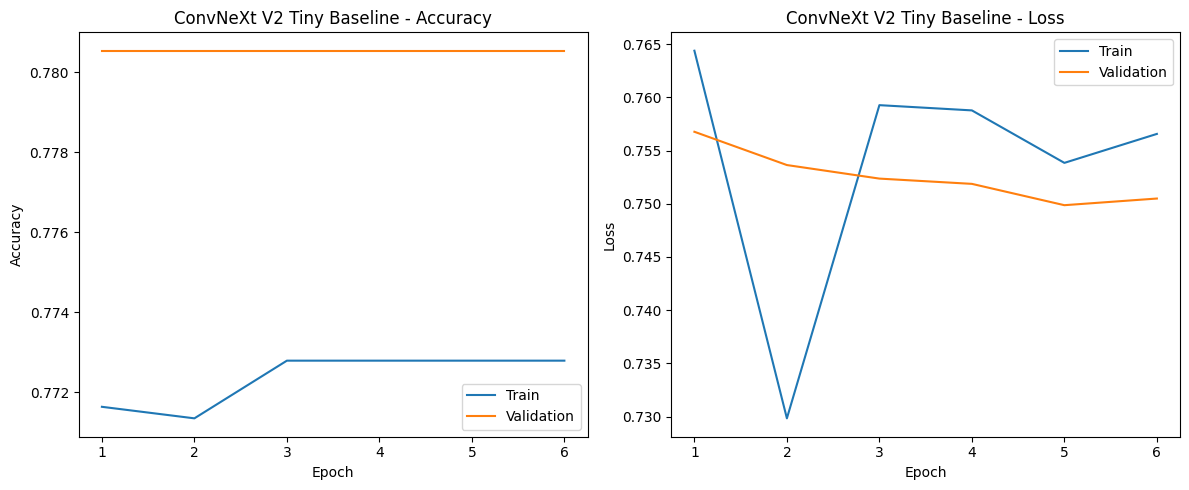

In [19]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_df["epoch"], hist_df["train_acc"], label="Train")
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="Validation")
plt.title("ConvNeXt V2 Tiny Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Validation")
plt.title("ConvNeXt V2 Tiny Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

print("Best ConvNeXt V2 Tiny checkpoint loaded.")
print("Best val acc from checkpoint:", ckpt["best_val_acc"])
print("Best epoch:", ckpt["best_epoch"])

Best ConvNeXt V2 Tiny checkpoint loaded.
Best val acc from checkpoint: 0.7805442964678634
Best epoch: 1


In [21]:
pad_loss, pad_acc, pad_probs, pad_preds, pad_true = evaluate(
    model, pad_loader, criterion, device
)

print("PAD Accuracy:", pad_acc)
print("PAD Loss:", pad_loss)

PAD Accuracy: 0.13041154462854088
PAD Loss: 2.746440975121927


In [22]:
acc = accuracy_score(pad_true, pad_preds)
prec = precision_score(pad_true, pad_preds, average="macro", zero_division=0)
rec = recall_score(pad_true, pad_preds, average="macro", zero_division=0)
f1 = f1_score(pad_true, pad_preds, average="macro", zero_division=0)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print(
    classification_report(
        pad_true,
        pad_preds,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.13041154462854088
Precision: 0.03260288615713522
Recall   : 0.25
F1 Score : 0.05768321513002364
              precision    recall  f1-score   support

         ACK       0.00      0.00      0.00       730
         BCC       0.00      0.00      0.00       845
         MEL       0.00      0.00      0.00        52
         NEV       0.13      1.00      0.23       244

    accuracy                           0.13      1871
   macro avg       0.03      0.25      0.06      1871
weighted avg       0.02      0.13      0.03      1871



In [23]:
pad_true_onehot = label_binarize(pad_true, classes=[0, 1, 2, 3])

auc = roc_auc_score(
    pad_true_onehot,
    pad_probs,
    average="macro",
    multi_class="ovr"
)

print("Macro AUC:", auc)

Macro AUC: 0.5047791449616617


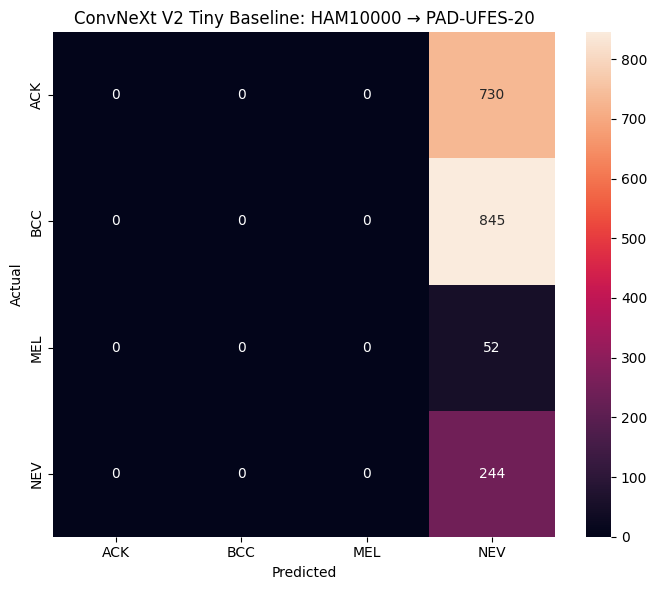

In [24]:
cm = confusion_matrix(pad_true, pad_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ConvNeXt V2 Tiny Baseline: HAM10000 → PAD-UFES-20")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
results = pd.DataFrame({
    "Experiment": ["ConvNeXt V2 Tiny Baseline"],
    "PAD Accuracy": [acc],
    "Macro Precision": [prec],
    "Macro Recall": [rec],
    "Macro F1": [f1],
    "Macro AUC": [auc]
})

print(results)
results.to_csv(OUT_DIR / "final_results.csv", index=False)

                  Experiment  PAD Accuracy  Macro Precision  Macro Recall  \
0  ConvNeXt V2 Tiny Baseline      0.130412         0.032603          0.25   

   Macro F1  Macro AUC  
0  0.057683   0.504779  


In [26]:
with open(OUT_DIR / "run_info.txt", "w") as f:
    f.write(f"Model: {model_name}\n")
    f.write(f"Best val acc: {best_val_acc}\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"PAD accuracy: {acc}\n")
    f.write(f"PAD precision: {prec}\n")
    f.write(f"PAD recall: {rec}\n")
    f.write(f"PAD f1: {f1}\n")
    f.write(f"PAD auc: {auc}\n")

print("All outputs saved in:", OUT_DIR)

All outputs saved in: E:\Thesis\outputs\convnextv2_tiny_baseline
